# WavesFM Finetuning Lab
<img src="https://raw.githubusercontent.com/AhmedTarek62/wavesfm/main/wavesfm.png" width="800">

This notebook is a full, hands-on lab for adapting WavesFM to downstream wireless tasks.

### In this lab, you will complete three tasks:
1) **Task 1 (HAS classification):** run finetuning experiments and report metrics for LP and FT2, with confusion-matrix results.
2) **Task 2 (UWB positioning):** complete parts of the finetuning loop, then report localization metrics and error plots.
3) **Task 3 (data efficiency):** compare LP pretrained vs LP supervised-from-scratch across multiple train fractions.

### Big-picture flow (end-to-end)
1) Set up the environment and workspace.
2) Download and inspect the prepared datasets.
3) Load a pretrained WavesFM checkpoint.
4) Run task-specific finetuning/evaluation pipelines.
5) Compare results across training setups and data regimes.

By the end, you will have:
- a complete finetuning workflow for classification and positioning,
- task metrics and plots,
- and a data-efficiency comparison between pretrained and supervised training.

### Runtime note
For best performance, run on **Google Colab with GPU runtime enabled**:
`Runtime -> Change runtime type -> GPU`.


## 0) Setup
This section prepares the environment and imports everything needed for the lab.

You should run these cells once at the beginning. If your environment already has the required packages, installation can be skipped.


### Core libraries and useful helpers

In [7]:
import subprocess
import sys
from pathlib import Path
import json
from dataclasses import dataclass
import math

# ---------- shell helpers ----------
def run_cmd(cmd, *, cwd=None, check=True):
    if isinstance(cmd, str):
        return subprocess.run(cmd, shell=True, cwd=cwd, check=check)
    return subprocess.run([str(c) for c in cmd], cwd=cwd, check=check)

# ---------- environment helper ----------
def is_colab() -> bool:
    return "google.colab" in sys.modules

# ---------- download helper ----------
def download_file(url: str, dst: Path):
    import gdown
    dst.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {url} -> {dst}")
    gdown.download(url=url, output=str(dst), quiet=False, fuzzy=True)
    return


### Install and import other dependencies if missing

In [ ]:
required_packages = ('torch', 
                     'torchvision', 
                     'timm', 
                     'tensorboard', 
                     'numpy', 
                     'tqdm', 
                     'matplotlib',
                     'gdown',
                     'h5py',
                     'huggingface_hub')
run_cmd([sys.executable, '-m', 'pip', 'install', '--quiet', *required_packages])

from tqdm.auto import tqdm
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import h5py
from typing import Optional
from timm.utils import accuracy
from timm.layers import trunc_normal_
import matplotlib.pyplot as plt


## 1) Create Workspace Folders
Define a small, reproducible project layout (`data/`, `outputs/`, `checkpoints/`).


In [9]:
ROOT = Path('.').resolve()
DATA_ROOT = ROOT / 'data'
OUTPUTS_DIR = ROOT / 'outputs'
CHECKPOINTS_DIR = ROOT / 'checkpoints'
WAVESFM_REPO = ROOT / 'wavesfm'

for p in [
    DATA_ROOT,
    OUTPUTS_DIR,
    CHECKPOINTS_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

print('Workspace folders are ready.')

Workspace folders are ready.


## 2) Load and Visualize Datasets
We use preprocessed `.h5` caches for both tasks:
- HAS classification cache (`has.h5`)
- UWB positioning cache (`uwb_positioning.h5`)

Before finetuning, we will visualize random samples to confirm that labels and signal formats look correct.


### Download datasets
Run once to download the two cache files into `data/`.


In [10]:
HAS_LINK = 'https://drive.google.com/file/d/1ORUnwurqOzP_RgBym7nXJVLYLE3qhj_l/view?usp=drive_link'
POS_LINK = 'https://drive.google.com/file/d/1a7khOwYo0GYdgU8TOftNR95eUBwggmwk/view?usp=drive_link'
download_file(HAS_LINK, DATA_ROOT / 'has.h5')
download_file(POS_LINK, DATA_ROOT / 'uwb_positioning.h5')

Downloading...
From (original): https://drive.google.com/uc?id=1ORUnwurqOzP_RgBym7nXJVLYLE3qhj_l
From (redirected): https://drive.google.com/uc?id=1ORUnwurqOzP_RgBym7nXJVLYLE3qhj_l&confirm=t&uuid=b516d8db-d383-4dc9-aeaa-53b65b361aa0
To: /home/ahmed/dev/wavesfm-lab/data/has.h5
100%|██████████| 771M/771M [00:28<00:00, 27.4MB/s] 


Downloading...
From (original): https://drive.google.com/uc?id=1a7khOwYo0GYdgU8TOftNR95eUBwggmwk
From (redirected): https://drive.google.com/uc?id=1a7khOwYo0GYdgU8TOftNR95eUBwggmwk&confirm=t&uuid=2c734beb-e51c-4d1c-bd31-72acf616e8b2
To: /home/ahmed/dev/wavesfm-lab/data/uwb_positioning.h5
100%|██████████| 1.03G/1.03G [00:40<00:00, 25.1MB/s]


### Dataset Classes
Each dataset class reads one cache file and returns a `(sample, target)` pair through `__getitem__`.

The goal is to keep loading logic simple and explicit so it is easy to debug.


#### Human activity sensing dataset class

In [11]:
class HASDataset(Dataset):
    def __init__(
        self,
        h5_path: Path,
        sample_key: str,
        label_key: str,
        label_dtype: Optional[torch.dtype] = torch.long,
    ):
        self.h5_path = Path(h5_path)
        self.sample_key = sample_key
        self.label_key = label_key
        self.label_dtype = label_dtype
        self._h5 = None

        with h5py.File(self.h5_path, "r") as h5:
            if sample_key not in h5 or label_key not in h5:
                raise KeyError(f"Missing '{sample_key}' or '{label_key}' in {self.h5_path}")
            self.length = int(h5[sample_key].shape[0])
            self.sample_shape = tuple(h5[sample_key].shape[1:])
            self.label_shape = tuple(h5[label_key].shape[1:])
            labels_attr = h5.attrs.get("labels", None)
            if labels_attr is not None:
                try:
                    self.label_names = list(json.loads(labels_attr))
                except Exception:
                    self.label_names = None
            else:
                self.label_names = None

    def __len__(self):
        return self.length

    def _file(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, "r")
        return self._h5

    def __getitem__(self, idx: int):
        h5 = self._file()
        x = torch.as_tensor(h5[self.sample_key][idx], dtype=torch.float32)
        if self.label_dtype is None:
            y = torch.as_tensor(h5[self.label_key][idx])
        else:
            y = torch.as_tensor(h5[self.label_key][idx], dtype=self.label_dtype)
        return x, y

    def all_labels(self) -> np.ndarray:
        with h5py.File(self.h5_path, "r") as h5:
            return np.asarray(h5[self.label_key]).reshape(-1)

    def __del__(self):
        if self._h5 is not None:
            try:
                self._h5.close()
            except Exception:
                pass

#### UWB CIR positioning dataset class

In [13]:
def _decode_attr(val):
    if isinstance(val, (bytes, np.bytes_)):
        return val.decode("utf-8")
    return val


def _parse_attr_list(val) -> tuple:
    if val is None:
        return ()
    val = _decode_attr(val)
    if isinstance(val, str):
        try:
            parsed = json.loads(val)
        except json.JSONDecodeError:
            return (val,)
        if isinstance(parsed, list):
            return tuple(parsed)
        return (parsed,)
    if isinstance(val, (list, tuple, np.ndarray)):
        out = []
        for item in val:
            item = _decode_attr(item)
            out.append(str(item))
        return tuple(out)
    return (str(val),)


def _pad_or_slice(arr: np.ndarray, target_len: int, pad_val: float) -> np.ndarray:
    arr = np.asarray(arr, dtype=np.float32).reshape(-1)
    if arr.size >= target_len:
        return arr[:target_len]
    pad = np.full((target_len - arr.size,), pad_val, dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)


class CIRLocDataset(Dataset):
    """
    Generic HDF5-backed CIR localization dataset.

    Expected HDF5 layout:
      - /cir: float32, shape (N, 2, A, L) storing real/imag parts
      - /location: float32, shape (N, D)
      - attrs: mean_real, mean_imag, std_real, std_imag (float)
      - attrs: loc_min (D,), loc_max (D,)
      - optional datasets: /channel, /anchor_mask, /rec_time, /burst_id
    """

    def __init__(
        self,
        h5_path: str | Path,
        *,
        return_mask: bool = False,
        return_meta: bool = False,
        return_channel: bool = False,
        as_complex: bool = False,
        location_dims: int | None = None,
    ) -> None:
        self.h5_path = str(Path(h5_path).expanduser())
        self.return_mask = bool(return_mask)
        self.return_meta = bool(return_meta)
        self.return_channel = bool(return_channel)
        self.as_complex = bool(as_complex)

        with h5py.File(self.h5_path, "r") as f:
            if "cir" not in f or "location" not in f:
                raise KeyError(f"Expected 'cir' and 'location' datasets in {self.h5_path}")
            cir_shape = f["cir"].shape
            loc_shape = f["location"].shape
            loc_dims = loc_shape[1] if len(loc_shape) > 1 else 1

            self.N = cir_shape[0]
            self.num_anchors = cir_shape[2]
            self.cir_len = cir_shape[3]

            self.location_dims = loc_dims if location_dims is None else int(location_dims)
            if self.location_dims <= 0:
                raise ValueError("location_dims must be positive.")
            if self.location_dims > loc_dims:
                raise ValueError("location_dims cannot exceed location dimension.")

            self.stats = {
                "mean": (
                    float(f.attrs.get("mean_real", 0.0)),
                    float(f.attrs.get("mean_imag", 0.0)),
                ),
                "std": (
                    float(f.attrs.get("std_real", 1.0)),
                    float(f.attrs.get("std_imag", 1.0)),
                ),
            }

            loc_min = f.attrs.get("loc_min", np.zeros(loc_dims, dtype=np.float32))
            loc_max = f.attrs.get("loc_max", np.ones(loc_dims, dtype=np.float32))
            loc_min = _pad_or_slice(loc_min, self.location_dims, 0.0)
            loc_max = _pad_or_slice(loc_max, self.location_dims, 1.0)
            self.loc_min = torch.tensor(loc_min, dtype=torch.float32)
            self.loc_max = torch.tensor(loc_max, dtype=torch.float32)

            anchors_attr = f.attrs.get("anchors", None)
            self.anchors = _parse_attr_list(anchors_attr)

            env_attr = f.attrs.get("environment", "")
            self.environment = str(_decode_attr(env_attr)) if env_attr is not None else ""

            fill_missing = f.attrs.get("fill_missing", "zero")
            self.fill_missing = str(_decode_attr(fill_missing)) if fill_missing is not None else "zero"

            self.has_mask = "anchor_mask" in f
            self.has_rec_time = "rec_time" in f
            self.has_burst_id = "burst_id" in f
            self.has_channel = "channel" in f

            if self.return_channel and not self.has_channel:
                raise KeyError(f"Requested return_channel, but 'channel' not found in {self.h5_path}")

        self._h5: Optional[h5py.File] = None

    def __len__(self) -> int:
        return self.N

    def _file(self) -> h5py.File:
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, "r")
        return self._h5

    def __getitem__(self, idx: int):
        f = self._file()
        cir_np = f["cir"][idx]  # (2, A, L)
        loc_np = f["location"][idx]
        loc_np = loc_np[: self.location_dims]

        cir = torch.from_numpy(cir_np).float()
        mean_real, mean_imag = self.stats["mean"]
        std_real, std_imag = self.stats["std"]
        std_real = std_real if std_real > 0 else 1.0
        std_imag = std_imag if std_imag > 0 else 1.0
        cir[0] = (cir[0] - mean_real) / std_real
        cir[1] = (cir[1] - mean_imag) / std_imag

        if self.fill_missing == "nan":
            nan_mask = torch.isnan(cir)
            if nan_mask.any():
                cir = cir.clone()
                cir[nan_mask] = 0.0

        if self.as_complex:
            cir = torch.complex(cir[0], cir[1])

        # pad L dimension to next power of two
        L = cir.shape[-1]
        target_L = 1 << (L - 1).bit_length()
        if target_L > L:
            pad_width = target_L - L
            if self.as_complex:
                cir = torch.nn.functional.pad(cir, (0, pad_width), value=0.0)
            else:
                cir = torch.nn.functional.pad(cir, (0, pad_width))

        loc_raw = torch.from_numpy(np.asarray(loc_np, dtype=np.float32))
        denom = (self.loc_max - self.loc_min).clamp_min(1e-6)
        loc = 2.0 * (loc_raw - self.loc_min) / denom - 1.0

        if self.return_meta:
            meta = {}
            if self.has_burst_id:
                meta["burst_id"] = int(f["burst_id"][idx])
            if self.has_rec_time:
                meta["rec_time"] = torch.from_numpy(f["rec_time"][idx]).long()
            if self.has_mask:
                meta["anchor_mask"] = torch.from_numpy(f["anchor_mask"][idx].astype(np.bool_))
            if self.has_channel:
                meta["channel"] = int(f["channel"][idx])
            return cir, loc, meta

        if self.return_mask:
            if self.has_mask:
                mask = torch.from_numpy(f["anchor_mask"][idx].astype(np.bool_))
            else:
                mask = torch.ones(self.num_anchors, dtype=torch.bool)
            return cir, loc, mask

        if self.return_channel:
            ch_val = int(f["channel"][idx])
            ch = torch.tensor(ch_val, dtype=torch.int16)
            return cir, loc, ch

        return cir, loc

    def __del__(self) -> None:
        if self._h5 is not None:
            try:
                self._h5.close()
            except Exception:
                pass

class UWBIndustrial(CIRLocDataset):
    def __init__(
        self,
        h5_path: str | Path,
        return_mask: bool = False,
        return_meta: bool = False,
        as_complex: bool = False,
    ) -> None:
        super().__init__(
            h5_path,
            return_mask=return_mask,
            return_meta=return_meta,
            as_complex=as_complex,
            location_dims=2,
        )

### Visualize Datasets
Before training, quickly inspect random samples from each dataset to verify data format and labels.


HAS samples: 1200
UWB samples: 15803


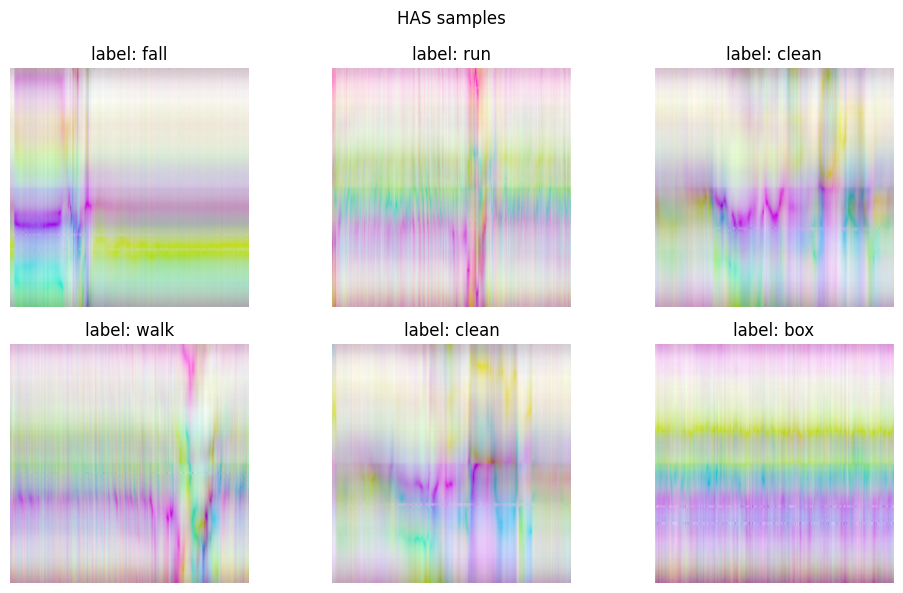

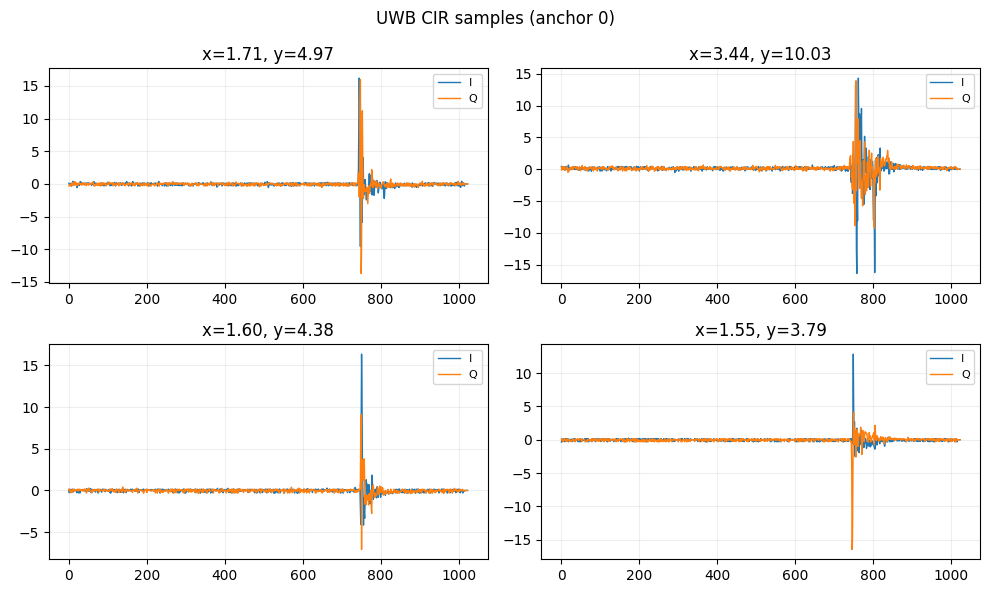

In [14]:
has_ds = HASDataset(DATA_ROOT / 'has.h5', sample_key='csi', label_key='label')
uwb_ds = UWBIndustrial(DATA_ROOT / 'uwb_positioning.h5')

print(f"HAS samples: {len(has_ds)}")
print(f"UWB samples: {len(uwb_ds)}")

has_names = has_ds.label_names if has_ds.label_names is not None else ['run', 'walk', 'fall', 'box', 'circle', 'clean']
rng = np.random.default_rng(42)

# HAS visualization
has_ids = rng.choice(len(has_ds), size=6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()
for ax, idx in zip(axes, has_ids):
    x, y = has_ds[int(idx)]
    img = x.numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = np.moveaxis(img, 0, -1)
    ax.imshow(img)
    ax.set_title(f"label: {has_names[int(y)]}")
    ax.axis('off')
plt.suptitle('HAS samples')
plt.tight_layout()
plt.show()

# UWB visualization
uwb_ids = rng.choice(len(uwb_ds), size=4, replace=False)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()
for ax, idx in zip(axes, uwb_ids):
    cir, loc = uwb_ds[int(idx)]
    anchor_id = 0
    i_sig = cir[0, anchor_id].numpy()
    q_sig = cir[1, anchor_id].numpy()

    loc_denorm = (loc + 1.0) * 0.5 * (uwb_ds.loc_max - uwb_ds.loc_min) + uwb_ds.loc_min
    x_pos, y_pos = loc_denorm[:2].numpy()

    ax.plot(i_sig, label='I', linewidth=1)
    ax.plot(q_sig, label='Q', linewidth=1)
    ax.set_title(f"x={x_pos:.2f}, y={y_pos:.2f}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
plt.suptitle('UWB CIR samples (anchor 0)')
plt.tight_layout()
plt.show()


## 3) Shared Learning and Optimization Utilties
These utilities are shared by all tasks and keep task cells focused on the assignment logic.


In [15]:
# ---------- optimization meters ----------
@dataclass
class AverageMeter:
    total: float = 0.0
    count: int = 0

    def update(self, value: float, n: int = 1):
        self.total += float(value) * n
        self.count += n

    @property
    def avg(self) -> float:
        return self.total / max(1, self.count)

# ---------- learning-rate utilities ----------
def cosine_schedule(base_lr: float, min_lr: float, steps: int, warmup_steps: int) -> list[float]:
    if steps <= 0:
        return []
    warmup_steps = min(warmup_steps, steps)
    sched = []
    for step in range(steps):
        if warmup_steps > 0 and step < warmup_steps:
            lr = base_lr * step / max(1, warmup_steps)
        else:
            progress = (step - warmup_steps) / max(1, steps - warmup_steps)
            lr = min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))
        sched.append(lr)
    return sched


def apply_lr(optimizer: torch.optim.Optimizer, lr: float):
    for group in optimizer.param_groups:
        scale = group.get("lr_scale", 1.0)
        group["lr"] = lr * scale


def get_layer_id_for_vit(name: str, num_layers: int) -> int:
    if name == "cls_token" or "pos_embed" in name:
        return 0
    if name.startswith((
        "patch_embed",
        "vis_patch_embed",
        "iq_segment_embed",
        "iq_ant_embed",
        "iq_downsampler",
        "channel_adapter",
    )):
        return 0
    if name.startswith("blocks"):
        return int(name.split(".")[1]) + 1
    return num_layers


def param_groups_lrd(model: nn.Module, weight_decay=0.05, layer_decay=0.75):
    param_groups = {}
    num_layers = len(model.blocks) + 1 if hasattr(model, "blocks") else 0
    layer_scales = [layer_decay ** (num_layers - i) for i in range(num_layers + 1)] if num_layers > 0 else [1.0]

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1:
            g_decay = "no_decay"
            this_decay = 0.0
        else:
            g_decay = "decay"
            this_decay = weight_decay

        layer_id = get_layer_id_for_vit(name, num_layers) if num_layers > 0 else 0
        group_name = f"layer_{layer_id}_{g_decay}"
        if group_name not in param_groups:
            param_groups[group_name] = {
                "lr_scale": layer_scales[layer_id] if num_layers > 0 else 1.0,
                "weight_decay": this_decay,
                "params": [],
            }
        param_groups[group_name]["params"].append(p)

    return list(param_groups.values())

# ---------- runtime helpers ----------
def make_grad_scaler(device: torch.device):
    enabled = device.type == "cuda"
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        return torch.amp.GradScaler(device="cuda", enabled=enabled)
    else:
        return torch.amp.GradScaler(enabled=enabled)


def build_loaders(train_ds, val_ds, batch_size: int, num_workers: int):
    pin_mem = torch.cuda.is_available()
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_mem,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_mem,
        drop_last=False,
    )
    return train_loader, val_loader

# ---------- shared train loop ----------
def train_one_epoch(
    model: nn.Module,
    loader,
    criterion,
    optimizer,
    scaler,
    device,
    *,
    task_type: str,
    lr_schedule: list[float],
    step_offset: int,
    accum_steps: int,
    max_grad_norm: Optional[float],
    print_freq: int = 50,
):
    model.train()
    use_amp = device.type == "cuda"

    loss_meter = AverageMeter()
    acc_meter = AverageMeter()

    optimizer.zero_grad(set_to_none=True)
    global_step = step_offset
    n_steps = len(loader)

    for step, (samples, targets) in enumerate(loader):
        if lr_schedule and step % accum_steps == 0:
            apply_lr(optimizer, lr_schedule[min(global_step, len(lr_schedule) - 1)])

        samples = samples.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        if task_type == "classification":
            targets = targets.long()

        with torch.autocast(device_type=device.type, enabled=use_amp):
            outputs = model(samples)
            loss = criterion(outputs, targets)

        loss_value = float(loss.item())
        loss = loss / accum_steps
        scaler.scale(loss).backward()

        should_step = (step + 1) % accum_steps == 0 or (step + 1) == n_steps
        if should_step:
            if max_grad_norm is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        loss_meter.update(loss_value, n=samples.size(0))

        if task_type == "classification":
            acc1, _ = accuracy(outputs, targets, topk=(1, min(3, outputs.shape[1])))
            acc_meter.update(float(acc1.item()), n=samples.size(0))

        if step % print_freq == 0 or (step + 1) == n_steps:
            msg = f"[train] step={step+1:04d}/{n_steps:04d} loss={loss_meter.avg:.4f}"
            if task_type == "classification":
                msg += f" acc1={acc_meter.avg:.2f}"
            msg += f" lr={optimizer.param_groups[0]['lr']:.2e}"
            print(msg)

        global_step += 1

    out = {"loss": loss_meter.avg}
    if task_type == "classification":
        out["acc1"] = acc_meter.avg
    return out


## 4) Clone WavesFM Repo & Download Model
This section prepares the WavesFM code and points to the pretrained checkpoint used for finetuning.


In [ ]:
if not WAVESFM_REPO.exists():
    run_cmd(["git", "clone", "https://github.com/AhmedTarek62/wavesfm", str(WAVESFM_REPO)])

if str(WAVESFM_REPO) not in sys.path:
    sys.path.insert(0, str(WAVESFM_REPO))

print("Using WavesFM repo:", WAVESFM_REPO)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")
HF_REPO = "ahmedaboulfo/wavesfm"
HF_FILE = "wavesfm-v1p0.pth"


### Useful helpers to load/save the model
These are small wrappers around model creation and checkpoint loading/saving.


In [ ]:
# ---------- model build helper ----------
def build_wavesfm_model(
    modality: str,
    num_outputs: int,
    in_chans: Optional[int],
    *,
    use_conditional_ln: bool = True,
    vis_img_size: int = 224,
):
    return models_vit.vit_multi_small(
        modality=modality,
        global_pool="token",
        num_outputs=num_outputs,
        vis_img_size=vis_img_size,
        vis_patch=16,
        vis_in_chans_actual=in_chans,
        iq_segment_len=16,
        iq_downsample=None,
        iq_target_len=256,
        use_conditional_ln=use_conditional_ln,
    )

# ---------- checkpoint helpers ----------
def load_finetune_weights(model: nn.Module, ckpt_path: Path, *, keep_head: bool = False):
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    msg = model.load_state_dict(state, strict=False)
    if (not keep_head) and hasattr(model, "head") and isinstance(model.head, nn.Linear):
        trunc_normal_(model.head.weight, std=2e-5)
    return msg

# ---------- finetuning mode helper ----------
def configure_finetune_mode(model: nn.Module, freeze_mode: str, frozen_blocks: Optional[int] = None):
    if freeze_mode == "full":
        return
    if freeze_mode == "lp":
        model.freeze_encoder()
    elif freeze_mode == "ft2":
        if frozen_blocks is None:
            frozen_blocks = max(1, len(model.blocks) // 2)
        model.freeze_encoder(frozen_blocks)
    else:
        raise ValueError(f"Unknown freeze_mode: {freeze_mode}")

    model.unfreeze_tokenizer()
    if hasattr(model, "unfreeze_conditional_ln"):
        model.unfreeze_conditional_ln()

# ---------- reporting + save helpers ----------
def count_params(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def save_checkpoint(path: Path, model: nn.Module, epoch: int, best_metric: float, config: dict):
    payload = {
        "model": model.state_dict(),
        "epoch": epoch,
        "best_metric": best_metric,
        "config": config,
    }
    torch.save(payload, path)


## ⚙️ Task 1: Finetune WavesFM on Human Activity Sensing (2 Marks)
### **Task requirements**
- #### 1) Modify the Task 1 configuration as you see fit. You should achieve **per-class accuracy (PCA) > 90%** on the validation set.
- #### 2) Run and report validation results for both setups: **LP** and **FT2**.
- #### 3) Use the provided confusion-matrix code to plot and report the confusion matrix for your best run.

#### Sample Confusion Matrix
<img src="https://waveslab.ai/detailed-eval/ft2/sensing/confusion_matrix.png" width="600"> 


### Configuration
Set the task hyperparameters used for Task 1 runs.


In [ ]:
# Task 1 configuration
TASK1_OUT = OUTPUTS_DIR / 'task1_has'
TASK1_OUT.mkdir(parents=True, exist_ok=True)
TASK1_EPOCHS = 20
TASK1_BATCH_SIZE = 256
TASK1_LR = 3e-4
TASK1_WEIGHT_DECAY = 0.05
FROZEN_BLOCKS = 8  # KEEP AT LEAST 6 BLOCKS FROZEN

### Evaluation Function
Evaluation logic that returns loss, accuracy metrics, and confusion counts.


In [ ]:
@torch.no_grad()
def task1_eval(model, loader, class_names, device, criterion):
    model.eval()
    conf = torch.zeros((len(class_names), len(class_names)), dtype=torch.long)
    loss_total = 0.0
    n_total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()
        with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            logits = model(x)
            loss = criterion(logits, y)
        pred = logits.argmax(dim=1)

        for t, p in zip(y.cpu(), pred.cpu()):
            conf[int(t), int(p)] += 1

        loss_total += float(loss.item()) * x.size(0)
        n_total += x.size(0)

    per_class_total = conf.sum(dim=1)
    per_class_correct = conf.diag()
    per_class_acc = torch.where(per_class_total > 0, 100.0 * per_class_correct.float() / per_class_total.float(), 0.0)
    pca = float(per_class_acc.mean().item())
    acc1 = 100.0 * float(per_class_correct.sum().item()) / max(1, int(conf.sum().item()))

    return {
        'loss': loss_total / max(1, n_total),
        'acc1': acc1,
        'pca': pca,
        'per_class_acc': per_class_acc.cpu().numpy(),
        'conf': conf.cpu().numpy(),
    }


### Load Data and Pretrained Model
Load HAS data, split train/validation, then initialize WavesFM from pretrained weights.


In [ ]:
# ---------- fixed seed for reproducible Task 1 comparisons ----------
torch.manual_seed(0)
np.random.seed(0)

# ---------- task data ----------
class_names = ['run', 'walk', 'fall', 'box', 'circle', 'clean']
full_ds = HASDataset(DATA_ROOT / 'has.h5', sample_key='csi', label_key='label')
val_size = int(len(full_ds) * 0.2)
train_size = len(full_ds) - val_size
gen = torch.Generator().manual_seed(0)
train_ds, val_ds = torch.utils.data.random_split(full_ds, [train_size, val_size], generator=gen)

train_loader = DataLoader(train_ds, batch_size=TASK1_BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=TASK1_BATCH_SIZE, shuffle=False, num_workers=2)

# ---------- model + pretrained init ----------
import models_vit
from hub import download_pretrained

model = models_vit.vit_multi_small(
    modality='vision',
    global_pool='token',
    num_outputs=len(class_names),
    vis_img_size=224,
    vis_patch=16,
    vis_in_chans_actual=3,
    iq_downsample=None,
    use_conditional_ln=True,
    iq_segment_len=16
)

pretrained_path = Path(download_pretrained(HF_REPO, filename=HF_FILE, cache_dir=str(CHECKPOINTS_DIR / 'wavesfm')))
ckpt = torch.load(pretrained_path, map_location='cpu', weights_only=False)
state = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
model.load_state_dict(state, strict=False)
trunc_normal_(model.head.weight, std=2e-5)

for p in model.blocks[:FROZEN_BLOCKS].parameters():
    p.requires_grad = False

model.unfreeze_tokenizer()
if hasattr(model, 'unfreeze_conditional_ln'):
    model.unfreeze_conditional_ln()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=TASK1_LR, weight_decay=TASK1_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TASK1_EPOCHS)
scaler = torch.amp.GradScaler(device=device.type, enabled=device.type == 'cuda')


### Finetuning Loop
Run training for the configured epochs and track the best checkpoint by validation PCA.


In [ ]:
best_pca = -1.0
best_state = None

for epoch in range(TASK1_EPOCHS):
    model.train()
    loss_total = 0.0
    n_total = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device).long()

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_total += float(loss.item()) * x.size(0)
        n_total += x.size(0)

    scheduler.step()
    val_stats = task1_eval(model, val_loader, class_names, device, criterion)
    train_loss = loss_total / max(1, n_total)

    print(f"Epoch {epoch+1:02d}/{TASK1_EPOCHS} | train_loss={train_loss:.4f} | val_acc1={val_stats['acc1']:.2f} | val_pca={val_stats['pca']:.2f}")

    if val_stats['pca'] > best_pca:
        best_pca = val_stats['pca']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
final_stats = task1_eval(model, val_loader, class_names, device, criterion)
print('\nTask 1 final metrics:')
print({k: v for k, v in final_stats.items() if k not in ['per_class_acc', 'conf']})

print('\nTask 1 per-class accuracy (%):')
for name, acc in zip(class_names, final_stats['per_class_acc']):
    print(f"{name:>10s}: {float(acc):6.2f}")


### Plot Confusion Matrix
Generate and save the raw-count confusion matrix for the best Task 1 model.


In [ ]:
conf = final_stats['conf']
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(conf, cmap='Blues')
ax.set_title('HAS Confusion Matrix (raw counts)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        ax.text(j, i, int(conf[i, j]), ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

np.save(TASK1_OUT / 'confusion_counts.npy', conf)
with open(TASK1_OUT / 'metrics.json', 'w') as f:
    json.dump({
        'loss': float(final_stats['loss']),
        'acc1': float(final_stats['acc1']),
        'pca': float(final_stats['pca']),
        'per_class_acc': [float(x) for x in final_stats['per_class_acc']],
        'class_names': class_names,
    }, f, indent=2)

torch.save({'model': model.state_dict()}, TASK1_OUT / 'best.pth')
print(f"Saved Task 1 outputs to: {TASK1_OUT}")


## ⚙️ Task 2: Finetune WavesFM on UWB CIR Positioning (2 Marks)
### **Task requirements**
- #### 1) Complete the marked parts of the finetuning loop where `write your code here` is shown. You will need this to run the task.
- #### 2) Modify the Task 2 configuration as you see fit. You should achieve **mean positioning error < 1 meter** on the validation set.
- #### 3) Run and report validation results for both setups: **LP** and **FT2**.
- #### 4) Use the provided evaluation and plotting code to report distance-error metrics and error distribution for your best run.

#### Sample Error Density
<img src='https://waveslab.ai/detailed-eval/ft2/uwb-industrial/error_pdf.png' width=600>


### Configuration
Set the task hyperparameters used for Task 2 runs.


In [ ]:
# Task 2 configuration
TASK2_OUT = OUTPUTS_DIR / 'task2_uwb'
TASK2_OUT.mkdir(parents=True, exist_ok=True)
TASK2_EPOCHS = 20
TASK2_BATCH_SIZE = 64
TASK2_LR = 3e-4
TASK2_WEIGHT_DECAY = 0.05
TASK2_FROZEN_BLOCKS = 8  # KEEP AT LEAST 6 BLOCKS FROZEN


### Evaluation Function
Evaluation logic that returns distance-error metrics on the validation set.


In [ ]:
@torch.no_grad()
def task2_eval(model, loader, device, criterion, coord_min, coord_max):
    model.eval()
    loss_total = 0.0
    n_total = 0
    errors = []

    def denorm(z):
        return (z + 1.0) * 0.5 * (coord_max - coord_min) + coord_min

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).float()

        with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            pred = model(x)
            loss = criterion(pred, y)

        pred_xy = denorm(pred)
        true_xy = denorm(y)
        dist = torch.linalg.norm(pred_xy - true_xy, dim=-1)
        errors.append(dist.detach().cpu())

        loss_total += float(loss.item()) * x.size(0)
        n_total += x.size(0)

    all_errors = torch.cat(errors, dim=0)
    return {
        'loss': loss_total / max(1, n_total),
        'mean_distance_error': float(all_errors.mean().item()),
        'median_distance_error': float(torch.median(all_errors).item()),
        'p75_distance_error': float(torch.quantile(all_errors, 0.75).item()),
        'p90_distance_error': float(torch.quantile(all_errors, 0.90).item()),
        'errors': all_errors.numpy(),
    }


### Load Data and Pretrained Model
Load UWB data, split train/validation, then initialize the IQ-mode WavesFM model.


In [ ]:
# ---------- fixed seed for reproducible Task 2 comparisons ----------
torch.manual_seed(0)
np.random.seed(0)

# ---------- task data ----------
full_ds = UWBIndustrial(DATA_ROOT / 'uwb_positioning.h5')
val_size = int(len(full_ds) * 0.2)
train_size = len(full_ds) - val_size
gen = torch.Generator().manual_seed(0)
train_ds, val_ds = torch.utils.data.random_split(full_ds, [train_size, val_size], generator=gen)

train_loader = DataLoader(train_ds, batch_size=TASK2_BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=TASK2_BATCH_SIZE, shuffle=False, num_workers=2)

# ---------- model + pretrained init ----------
import models_vit
from hub import download_pretrained

sample_x, sample_y = full_ds[0]
model = models_vit.vit_multi_small(
    modality='iq',
    global_pool='token',
    num_outputs=int(sample_y.numel()),
    vis_img_size=224,
    vis_patch=16,
    iq_segment_len=16,
    iq_downsample=None,
    use_conditional_ln=True,
)

pretrained_path = Path(download_pretrained(HF_REPO, filename=HF_FILE, cache_dir=str(CHECKPOINTS_DIR / 'wavesfm')))
ckpt = torch.load(pretrained_path, map_location='cpu', weights_only=False)
state = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
model.load_state_dict(state, strict=False)
trunc_normal_(model.head.weight, std=2e-5)

for p in model.blocks[:TASK2_FROZEN_BLOCKS].parameters():
    p.requires_grad = False

model.unfreeze_tokenizer()
if hasattr(model, 'unfreeze_conditional_ln'):
    model.unfreeze_conditional_ln()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=TASK2_LR, weight_decay=TASK2_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TASK2_EPOCHS)
scaler = torch.amp.GradScaler(device=device.type, enabled=device.type == 'cuda')
coord_min = full_ds.loc_min.to(device)
coord_max = full_ds.loc_max.to(device)


### Finetuning Loop
Run finetuning and keep the model with the best (lowest) mean distance error.


In [ ]:
# Task 2 finetuning loop
best_mean = 1e9
best_state = None

for epoch in range(TASK2_EPOCHS):
    model.train()
    loss_total = 0.0
    n_total = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device).float()

        # TODO(Student) START: training step
        '''write your code here'''
        # TODO(Student) END

        loss_total += float(loss.item()) * x.size(0)
        n_total += x.size(0)

    scheduler.step()
    val_stats = task2_eval(model, val_loader, device, criterion, coord_min, coord_max)
    train_loss = loss_total / max(1, n_total)

    print(
        f"Epoch {epoch+1:02d}/{TASK2_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_mean={val_stats['mean_distance_error']:.3f} | "
        f"val_p90={val_stats['p90_distance_error']:.3f}"
    )

    # TODO(Student) START: model-selection update
    '''write your code here'''
    # TODO(Student) END

model.load_state_dict(best_state)
final_stats_task2 = task2_eval(model, val_loader, device, criterion, coord_min, coord_max)
print('\nTask 2 final metrics:')
print({k: v for k, v in final_stats_task2.items() if k != 'errors'})


### Plot Error Distribution
Generate and save the error-distribution plot for the best model.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(final_stats_task2['errors'], bins=50, color='tab:blue', alpha=0.8)
ax.axvline(np.mean(final_stats_task2['errors']), color='tab:red', linestyle='--', linewidth=1.5)
ax.set_title('UWB Position Error Distribution')
ax.set_xlabel('Distance error')
ax.set_ylabel('Count')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

np.save(TASK2_OUT / 'position_errors.npy', final_stats_task2['errors'])
with open(TASK2_OUT / 'metrics.json', 'w') as f:
    json.dump({
        'loss': float(final_stats_task2['loss']),
        'mean_distance_error': float(final_stats_task2['mean_distance_error']),
        'median_distance_error': float(final_stats_task2['median_distance_error']),
        'p75_distance_error': float(final_stats_task2['p75_distance_error']),
        'p90_distance_error': float(final_stats_task2['p90_distance_error']),
    }, f, indent=2)

torch.save({'model': model.state_dict()}, TASK2_OUT / 'best.pth')
print(f"Saved Task 2 outputs to: {TASK2_OUT}")


## ⚙️ Task 3: Investigate WavesFM Data Efficiency vs Supervised Learning on Human Activity Sensing (4 Marks)

### In this task, you will compare two training setups with the **same architecture** and **same training recipe**, both in **LP mode**:
1) **Pretrained LP**: initialize from WavesFM pretrained weights and run linear probing.
2) **Supervised LP**: initialize the same model randomly and run linear probing.

Use one fixed train/validation split from the beginning. For each fraction, subset only from the train split using the provided stratified split, and always evaluate on the same validation split.

### **Task requirements**
- #### 1) Keep both setups in **LP mode** for all training fractions.
- #### 2) Complete selected parts of the **runner skeleton** where indicated by `write your code here` prompts.
- #### 3) Use the provided **stratified split** helper to run the fraction sweep.
- #### 4) Generate the final comparison plot and report the results.


### Configuration
Set the fraction list and optimization hyperparameters for Task 3.


In [ ]:
# Task 3 configuration
TASK3_OUT = OUTPUTS_DIR / 'task3_data_efficiency'
TASK3_OUT.mkdir(parents=True, exist_ok=True)
TASK3_EPOCHS = 20
TASK3_BATCH_SIZE = 256
TASK3_LR = 1e-3
TASK3_WEIGHT_DECAY = 0.05
TASK3_FRACTIONS = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]


### Evaluation Function
Evaluation logic that returns the classification metric used by the Task 3 runner.


In [ ]:
@torch.no_grad()
def task3_eval(model, loader, class_names, device, criterion):
    model.eval()
    conf = torch.zeros((len(class_names), len(class_names)), dtype=torch.long)
    loss_total = 0.0
    n_total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()
        with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            logits = model(x)
            loss = criterion(logits, y)
        pred = logits.argmax(dim=1)

        for t, p in zip(y.cpu(), pred.cpu()):
            conf[int(t), int(p)] += 1

        loss_total += float(loss.item()) * x.size(0)
        n_total += x.size(0)

    per_class_total = conf.sum(dim=1)
    per_class_correct = conf.diag()
    per_class_acc = torch.where(per_class_total > 0, 100.0 * per_class_correct.float() / per_class_total.float(), 0.0)

    return {
        'loss': loss_total / max(1, n_total),
        'pca': float(per_class_acc.mean().item()),
    }


### Load Data and Define Training Helper
Load HAS data once, then define stratified-subset and runner helpers used by the fraction sweep.


In [ ]:
# ---------- fixed seed for reproducible Task 3 comparisons ----------
torch.manual_seed(0)
np.random.seed(0)

# ---------- task data ----------
full_ds = HASDataset(DATA_ROOT / 'has.h5', sample_key='csi', label_key='label')
class_names = full_ds.label_names if full_ds.label_names is not None else ['run', 'walk', 'fall', 'box', 'circle', 'clean']
labels_all = full_ds.all_labels()

val_size = int(len(full_ds) * 0.2)
train_size = len(full_ds) - val_size
gen = torch.Generator().manual_seed(0)
train_ds, val_ds = torch.utils.data.random_split(full_ds, [train_size, val_size], generator=gen)
base_train_idx = np.array(train_ds.indices)

# Provided: stratified subset helper
def make_stratified_subset(train_indices, fraction):
    if fraction >= 1.0:
        return train_indices

    rng = np.random.default_rng(0)
    picked = []
    for cls in np.unique(labels_all[train_indices]):
        cls_idx = train_indices[labels_all[train_indices] == cls]
        k = max(1, int(round(len(cls_idx) * fraction)))
        k = min(k, len(cls_idx))
        pick = rng.choice(cls_idx, size=k, replace=False)
        picked.extend(pick.tolist())
    rng.shuffle(picked)
    return np.array(picked)

# TODO(Student): complete selected parts of the runner skeleton
def run_task3_setting(train_indices, use_pretrained):
    torch.manual_seed(0)
    np.random.seed(0)

    train_subset = torch.utils.data.Subset(full_ds, train_indices.tolist())

    train_loader = DataLoader(train_subset, batch_size=TASK3_BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=TASK3_BATCH_SIZE, shuffle=False, num_workers=2)

    # TODO(Student) START: model setup
    '''write your code here'''
    # TODO(Student) END

    best_pca = -1.0
    for epoch in range(TASK3_EPOCHS):
        model.train()

        # TODO(Student) START: epoch training pass
        '''write your code here'''
        # TODO(Student) END

        scheduler.step()
        val_stats = task3_eval(model, val_loader, class_names, device, criterion)
        best_pca = max(best_pca, val_stats['pca'])

    return best_pca


### Run Data-Efficiency Experiment
Run pretrained and supervised baselines for each training fraction.


In [ ]:
rows = []
for frac in TASK3_FRACTIONS:
    subset_idx = make_stratified_subset(base_train_idx, frac)
    print(f"Running fraction={frac:.2f} ({len(subset_idx)} samples)")

    pca_pre = run_task3_setting(subset_idx, use_pretrained=True)
    pca_sup = run_task3_setting(subset_idx, use_pretrained=False)

    rows.append({
        'fraction': float(frac),
        'num_samples': int(len(subset_idx)),
        'pca_pretrained': float(pca_pre),
        'pca_supervised': float(pca_sup),
    })


### Plot and Save Results
Generate and save the final data-efficiency comparison figure and JSON summary.


In [ ]:
fractions = np.array([r['fraction'] for r in rows]) * 100.0
pca_pre = np.array([r['pca_pretrained'] for r in rows])
pca_sup = np.array([r['pca_supervised'] for r in rows])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(fractions, pca_pre, marker='o', linewidth=2, label='WavesFM pretrained init')
ax.plot(fractions, pca_sup, marker='s', linewidth=2, label='Random init supervised')
ax.set_xlabel('Training subset size (%)')
ax.set_ylabel('Per-class accuracy (PCA, %)')
ax.set_title('Data Efficiency on HAS')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

with open(TASK3_OUT / 'data_efficiency.json', 'w') as f:
    json.dump(rows, f, indent=2)

fig.savefig(TASK3_OUT / 'data_efficiency_curve.png', dpi=220)
print(f"Saved Task 3 outputs to: {TASK3_OUT}")


## Deliverables
### Submit one **fully runnable notebook** (`wavesfm_finetuning.ipynb`) containing your implementations for Tasks 1–3. The notebook should run end-to-end and produce:
- #### Task 1: final metrics + confusion matrix
- #### Task 2: final metrics + error-distribution plot
- #### Task 3: data-efficiency comparison plot
